In [1]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
X = pd.read_pickle('../data/fuzzy_x_20240106_values.pkl')
shap_values = np.load('../data/fuzzy_xgb_20240106_shap_values.npy')
shap_interaction_values = np.load('../data/fuzzy_xgb_20240106_shap_interaction_values.npy')

In [3]:
X = X.round(4)
shap_values = np.round(shap_values, 4)
shap_interaction_values = np.round(shap_interaction_values, 4)

In [4]:
variable_A_name = "Sh_3(mu)"
variable_A_index = X.columns.get_loc(variable_A_name)
variable_B_name = "Tipo P"
variable_B_index = X.columns.get_loc(variable_B_name)

In [5]:
from cgt_perezsechi.exploration.sampling import sample_size_kruskal_wallis

sample_size = sample_size_kruskal_wallis(X, shap_values, variable_A_name, acceleration=1)
if sample_size < len(X) / 10:
    sample_size = len(X) // 10

In [6]:
from cgt_perezsechi.manipulation.coding import code_interval

X_coded = code_interval(X, variable_A_name, sample_size)
df_A = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    'shap': shap_values[:, X.columns.get_loc(variable_A_name)]
})

In [7]:
df_B = pd.DataFrame({
    variable_B_name: X[variable_B_name],
    'shap': shap_values[:, X.columns.get_loc(variable_B_name)]
})

## Construcción de matrices de adyacencia

In [8]:
shap_interaction_values_A_B = shap_interaction_values[:, variable_A_index, variable_B_index]
df_interaction = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    variable_B_name: X_coded[variable_B_name],
    'shap_interaction': shap_interaction_values_A_B
})
df_interaction_grouped = df_interaction.groupby([variable_A_name, variable_B_name]).agg(["mean"]).reset_index()
df_interaction_grouped.columns = [variable_A_name, variable_B_name, 'shap_interaction']
df_interaction_grouped

,Sh_3(mu),Tipo P,shap_interaction
0,"[0.0,0.1157]",0,0.036993
1,"[0.0,0.1157]",1,-0.039052
2,"[0.1158,0.1808]",0,0.035973
3,"[0.1158,0.1808]",1,-0.039924
4,"[0.1811,0.2283]",0,0.021645
5,"[0.1811,0.2283]",1,-0.023478
6,"[0.2293,0.2753]",0,-0.004282
7,"[0.2293,0.2753]",1,0.004671
8,"[0.2756,0.3367]",0,-0.010178
9,"[0.2756,0.3367]",1,0.011833


In [9]:
unique_A_values = df_interaction_grouped[variable_A_name].unique()
unique_B_values = df_interaction_grouped[variable_B_name].unique()
variable_A_column_names = [f"{variable_A_name}_{value}" for value in unique_A_values]
variable_B_column_names = [f"{variable_B_name}_{value}" for value in unique_B_values]
column_names = variable_A_column_names + variable_B_column_names
r = pd.DataFrame(
    columns=column_names,
)

for A_value in unique_A_values:
    for B_value in unique_B_values:
        index_A = f"{variable_A_name}_{A_value}" 
        index_B = f"{variable_B_name}_{B_value}" 
        shap_interaction = df_interaction_grouped[
            (df_interaction_grouped[variable_A_name] == A_value) &
            (df_interaction_grouped[variable_B_name] == B_value)
        ]['shap_interaction'].values[0]
        r.loc[index_A, index_B] = shap_interaction
        r.loc[index_B, index_A] = shap_interaction

r.replace(np.nan, 0, inplace=True)
r_1 = r

C:\Users\secci\AppData\Local\Temp\ipykernel_26004\2317974099.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r.replace(np.nan, 0, inplace=True)


In [10]:
r_1

,"Sh_3(mu)_[0.0,0.1157]","Sh_3(mu)_[0.1158,0.1808]","Sh_3(mu)_[0.1811,0.2283]","Sh_3(mu)_[0.2293,0.2753]","Sh_3(mu)_[0.2756,0.3367]","Sh_3(mu)_[0.3367,0.6572]",Tipo P_0,Tipo P_1
"Sh_3(mu)_[0.0,0.1157]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.036993,-0.039052
Tipo P_0,0.036993,0.035973,0.021645,-0.004282,-0.010178,-0.030217,0.000000,0.000000
Tipo P_1,-0.039052,-0.039924,-0.023478,0.004671,0.011833,0.033930,0.000000,0.000000
"Sh_3(mu)_[0.1158,0.1808]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035973,-0.039924
"Sh_3(mu)_[0.1811,0.2283]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021645,-0.023478
"Sh_3(mu)_[0.2293,0.2753]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.004282,0.004671
"Sh_3(mu)_[0.2756,0.3367]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010178,0.011833
"Sh_3(mu)_[0.3367,0.6572]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.030217,0.033930


## Representación en grafo de la interacción entre valores de las variables "age" y "sex_isFemale"

In [11]:
df_A_stats = df_A.groupby(variable_A_name).agg(['mean']).reset_index()
df_A_stats.columns = [variable_A_name, 'shap']
df_B_stats = df_B.groupby(variable_B_name).agg(['mean']).reset_index()
df_B_stats.columns = [variable_B_name, 'shap']

In [12]:
df_A_stats

,Sh_3(mu),shap
0,"[0.0,0.1157]",0.381383
1,"[0.1158,0.1808]",0.420441
2,"[0.1811,0.2283]",0.306521
3,"[0.2293,0.2753]",0.128451
4,"[0.2756,0.3367]",0.028503
5,"[0.3367,0.6572]",-0.392096


In [13]:
psi_1 = pd.DataFrame(
    columns=['value'],
)

for index, row in df_A_stats.iterrows():
    psi_1.loc[f'{variable_A_name}_{row[variable_A_name]}', 'value'] = row['shap']
for index, row in df_B_stats.iterrows():
    psi_1.loc[f'{variable_B_name}_{row[variable_B_name]:.0f}', 'value'] = row['shap']

psi_1.index.name = None
psi_1

,value
"Sh_3(mu)_[0.0,0.1157]",0.381383
"Sh_3(mu)_[0.1158,0.1808]",0.420441
"Sh_3(mu)_[0.1811,0.2283]",0.306521
"Sh_3(mu)_[0.2293,0.2753]",0.128451
"Sh_3(mu)_[0.2756,0.3367]",0.028503
"Sh_3(mu)_[0.3367,0.6572]",-0.392096
Tipo P_0,0.213022
Tipo P_1,-0.212687


In [14]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r

psi_2 = normalize_psi(psi_1)
r_2 = normalize_r(r_1)

c:\Workspace\fuzzieee-2025\fuzzieee-2025-python\.venv\Lib\site-packages\cgt_perezsechi\manipulation\norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
c:\Workspace\fuzzieee-2025\fuzzieee-2025-python\.venv\Lib\site-packages\cgt_perezsechi\manipulation\norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


c:\Workspace\fuzzieee-2025\fuzzieee-2025-python\.venv\Lib\site-packages\cgt_perezsechi\visualization\graph.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
c:\Workspace\fuzzieee-2025\fuzzieee-2025-python\.venv\Lib\site-packages\cgt_perezsechi\visualization\graph.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


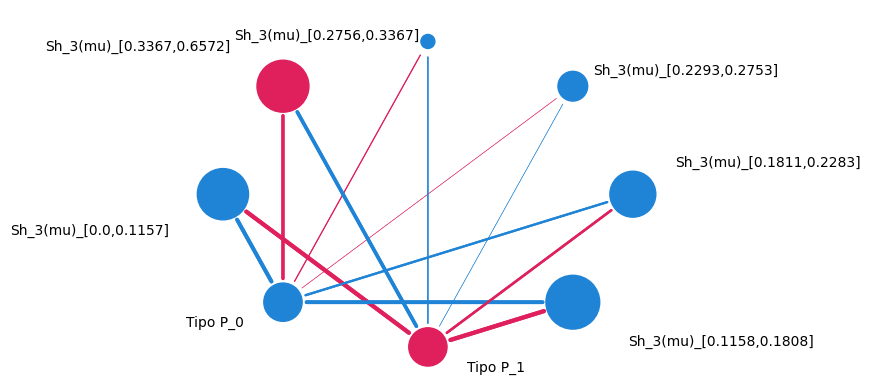

In [15]:
from cgt_perezsechi.visualization.graph import draw

positive_alpha = 0
negative_alpha = 0
positive_beta = 0
negative_beta = 0
draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    positive_color="#2084d6",
    negative_color="#df205d",
    layout="shell",
    node_label_size_limit=5000
)